# 花学测试·真实分布首报

## tl;dr

- 截至 2026-09-07 10:40（Asia/Shanghai），匿名事件共记录 382 次开始、332 次完成，完成/开始为 86.9%。
- 真实主型分布明显不同于完全随机作答基线，但随机基线不是真人目标分布，因此不能单据显著性调题。
- 9 月 4–6 日三个完整日的七型构成未检出日际差异（卡方同质性 p=0.739），说明偏斜方向在当前样本中基本稳定。
- 生产事件只记录最终主型，无法将偏差定位到题目/选项；建议暂时冻结模型，先完成口径和发布门禁收口。

## Context & Methods

分析目标是判断当前 Question Set v3.2 / Matrix v3.1 / Archetype Coordinates v2.1 是否应立即调整，以及如何处置严格诊断中 R 维度 10 题覆盖的已知超界。

### Key Assumptions

- GoatCounter `no_session` 事件计数单位是触发人次，不是独立用户。
- 随机基线表示答案空间的分类地盘，不是预期真人分布。
- 9 月 7 日是部分日；稳定性检查仅使用 9 月 4–6 日完整日。
- 9 月 3 日的前 12 次完成可能混合模型升级前后的构建，仅占总样本 3.6%。

In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare, chi2_contingency

SEARCH_ROOTS = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next((path for path in SEARCH_ROOTS if (path / "package.json").exists()), None)
if ROOT is None:
    raise FileNotFoundError("未能向上找到包含 package.json 的项目根目录")
SNAPSHOT_PATH = ROOT / "docs/analysis/real-distribution-snapshot-2026-09-07.json"
with SNAPSHOT_PATH.open(encoding="utf-8") as f:
    snapshot = json.load(f)

ARCHETYPES = [
    ("mao", "毛阿敏型"), ("xu", "许晴型"), ("ning", "宁静型"),
    ("zheng", "郑爽型"), ("chen", "陈意涵型"),
    ("jing", "井柏然型"), ("yang", "杨洋型"),
]
ids = [item[0] for item in ARCHETYPES]
names = {key: value for key, value in ARCHETYPES}
counts = np.array([snapshot["completions"][key] for key in ids])
baseline = np.array([snapshot["randomBaseline"]["primaryShares"][key] for key in ids])
baseline = baseline / baseline.sum()
n = int(counts.sum())
assert n == snapshot["funnel"]["complete"] == 332
assert counts.min() >= 0 and math.isclose(float(baseline.sum()), 1.0)
n

332

## Data

主数据为 GoatCounter 在 2026-09-01 至 2026-09-07 10:40 之间的匿名聚合事件。比较基线来自仓库内固定 seed 的 50 万次完全随机作答模拟。

In [2]:
start = snapshot["funnel"]["start"]
complete = snapshot["funnel"]["complete"]
shares = snapshot["funnel"]["shareActions"]
share_total = sum(shares.values())
funnel = pd.DataFrame([
    {"指标": "开始测试", "人次": start, "相对开始": 1.0},
    {"指标": "完成鉴定", "人次": complete, "相对开始": complete / start},
    {"指标": "分享动作", "人次": share_total, "相对开始": share_total / start},
])
funnel

,指标,人次,相对开始
0,开始测试,382,1.000000
1,完成鉴定,332,0.869110
2,分享动作,133,0.348168


In [3]:
def wilson_interval(successes, total, z=1.959963984540054):
    p = successes / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    half = z * math.sqrt(p*(1-p)/total + z*z/(4*total*total)) / denominator
    return center - half, center + half

actual = counts / n
expected = baseline * n
rows = []
for index, key in enumerate(ids):
    low, high = wilson_interval(int(counts[index]), n)
    rows.append({
        "id": key,
        "人格": names[key],
        "完成人次": int(counts[index]),
        "真实占比": actual[index],
        "95%CI下限": low,
        "95%CI上限": high,
        "随机基线": baseline[index],
        "差值pp": (actual[index] - baseline[index]) * 100,
        "相对基线倍率": actual[index] / baseline[index],
        "Pearson残差": (counts[index] - expected[index]) / math.sqrt(expected[index]),
    })
distribution = pd.DataFrame(rows)
distribution.style.format({
    "真实占比": "{:.1%}", "95%CI下限": "{:.1%}", "95%CI上限": "{:.1%}",
    "随机基线": "{:.1%}", "差值pp": "{:+.1f}", "相对基线倍率": "{:.2f}", "Pearson残差": "{:+.2f}",
})

,id,人格,完成人次,真实占比,95%CI下限,95%CI上限,随机基线,差值pp,相对基线倍率,Pearson残差
0,mao,毛阿敏型,61,18.4%,14.6%,22.9%,9.4%,+9.0,1.96,+5.35
1,xu,许晴型,11,3.3%,1.9%,5.8%,14.9%,-11.6,0.22,-5.48
2,ning,宁静型,31,9.3%,6.7%,12.9%,12.2%,-2.9,0.77,-1.49
3,zheng,郑爽型,18,5.4%,3.5%,8.4%,19.8%,-14.4,0.27,-5.90
4,chen,陈意涵型,43,13.0%,9.8%,17.0%,10.5%,+2.5,1.23,+1.38
5,jing,井柏然型,52,15.7%,12.1%,20.0%,11.0%,+4.7,1.43,+2.58
6,yang,杨洋型,116,34.9%,30.0%,40.2%,22.2%,+12.7,1.57,+4.93


## Results

### 真实分布与随机答案空间显著不同

差异最大的是杨洋型（+12.7pp）、郑爽型（-14.4pp）、许晴型（-11.6pp）和毛阿敏型（+9.0pp）。这证明真实选择不是均匀随机，但不能单独证明评分模型错误。

In [4]:
chi = chisquare(counts, expected)
tv_distance = 0.5 * np.abs(actual - baseline).sum()
mix = 0.5 * (actual + baseline)
js_bits = 0.5 * np.sum(actual * np.log2(actual / mix)) + 0.5 * np.sum(baseline * np.log2(baseline / mix))
{
    "chi_square": float(chi.statistic),
    "degrees_of_freedom": len(ids) - 1,
    "p_value": float(chi.pvalue),
    "total_variation_distance": float(tv_distance),
    "jensen_shannon_divergence_bits": float(js_bits),
}

{'chi_square': 128.57697222341343,
 'degrees_of_freedom': 6,
 'p_value': 2.56218394930523e-25,
 'total_variation_distance': 0.288977108433735,
 'jensen_shannon_divergence_bits': 0.08680078837164548}

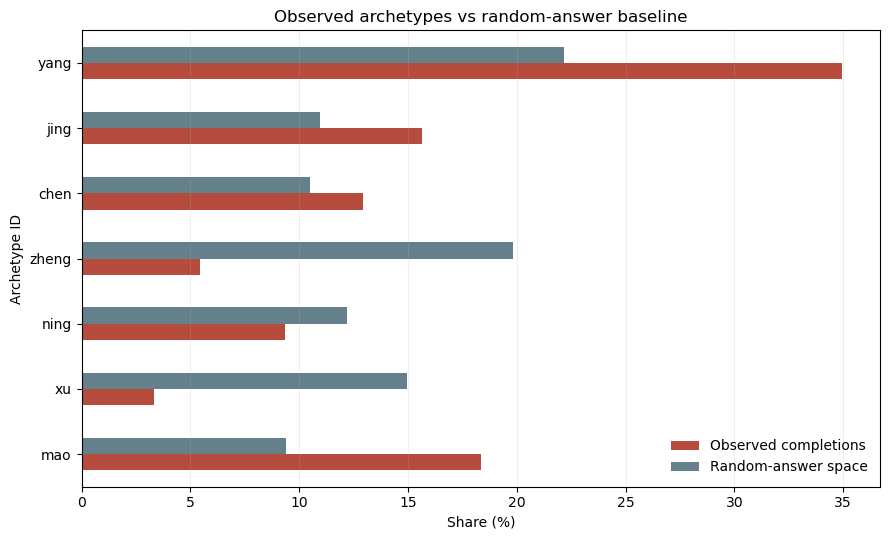

In [5]:
plot_df = distribution[["id", "真实占比", "随机基线"]].set_index("id") * 100
ax = plot_df.plot(kind="barh", figsize=(9, 5.5), color=["#b64c3e", "#64818b"])
ax.set_title("Observed archetypes vs random-answer baseline")
ax.set_xlabel("Share (%)")
ax.set_ylabel("Archetype ID")
ax.legend(["Observed completions", "Random-answer space"], frameon=False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### 发布后三个完整日的偏斜方向基本稳定

9 月 4–6 日分别有 180、82、48 次完成。卡方同质性检验未发现三天构成有统计显著差异，因此当前偏斜不太像是某一天的偶然流量造成。但小类别的单日期望数较低，这项检验只能作为方向性证据。

In [6]:
cumulative = snapshot["cumulativeByEndDate"]
complete_days = []
for previous, current in zip(cumulative[:3], cumulative[1:4]):
    row = {"date": previous["end"]}
    # end 参数是区间上界：当日值 = 下一个累计点 - 当前累计点
    for key in ids:
        row[key] = current["completions"][key] - previous["completions"][key]
    complete_days.append(row)
daily = pd.DataFrame(complete_days)
daily["total"] = daily[ids].sum(axis=1)
contingency = daily[ids].to_numpy()
homogeneity = chi2_contingency(contingency)
daily_display = daily.rename(columns={**names, "date": "日期", "total": "完成人次"})
print({"chi_square": homogeneity.statistic, "dof": homogeneity.dof, "p_value": homogeneity.pvalue})
daily_display

{'chi_square': 8.575871043262135, 'dof': 12, 'p_value': 0.7386659313537143}


,日期,毛阿敏型,许晴型,宁静型,郑爽型,陈意涵型,井柏然型,杨洋型,完成人次
0,2026-09-04,29,6,18,10,23,31,63,180
1,2026-09-05,19,1,6,5,9,9,33,82
2,2026-09-06,10,2,7,2,8,6,13,48


## Takeaways

1. **当前不应直接调题或调坐标。** 最终类型聚合数据能证明分布偏斜，但无法证明哪一题或哪一个参数造成偏斜。
2. **严格门禁应区分“理想目标”和“已批准发布例外”。** R=10 保留为显式告警，但对当前 v3.2/v2.1 不再阻断发布；其他 G2–G6 失败仍应阻断。
3. **下一次内容改版要先补足可归因证据。** 优先做小样本、明确同意的真人认知访谈/受控作答，而不是在生产环境上传原始答案。
4. **分析口径需持续版本化。** 当题库、矩阵或坐标再次变更时，应使新旧完成事件可分开统计，否则真实分布会混版本。